In [229]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [230]:
data = pd.read_csv('Main Data_SOM.csv')
data.head()

,Index,d__Archaea;__;__;__;__;__,d__Archaea;p__Euryarchaeota;c__Methanobacteria;o__Methanobacteriales;f__Methanobacteriaceae;g__Methanobrevibacter,d__Archaea;p__Euryarchaeota;c__Methanobacteria;o__Methanobacteriales;f__Methanobacteriaceae;g__Methanosphaera,d__Archaea;p__Halobacterota;c__Methanomicrobia;o__Methanomicrobiales;f__Methanocorpusculaceae;g__Methanocorpusculum,d__Archaea;p__Halobacterota;c__Methanomicrobia;o__Methanomicrobiales;f__Methanomicrobiaceae;g__Methanoculleus,d__Archaea;p__Halobacterota;c__Methanomicrobia;o__Methanomicrobiales;f__Methanomicrobiaceae;g__Methanomicrobium,d__Archaea;p__Halobacterota;c__Methanomicrobia;o__Methanomicrobiales;f__Methanomicrobiaceae;g__uncultured,d__Archaea;p__Halobacterota;c__Methanosarcinia;o__Methanosarciniales;f__Methanosarcinaceae;g__Methanimicrococcus,d__Archaea;p__Halobacterota;c__Methanosarcinia;o__Methanosarciniales;f__Methanosarcinaceae;g__Methanosarcina,...,d__Bacteria;p__Verrucomicrobiota;c__Verrucomicrobiae;o__Opitutales;f__Puniceicoccaceae;g__Verruc-01,d__Bacteria;p__Verrucomicrobiota;c__Verrucomicrobiae;o__Pedosphaerales;f__Pedosphaeraceae;g__DEV114,d__Bacteria;p__Verrucomicrobiota;c__Verrucomicrobiae;o__uncultured;f__uncultured;g__uncultured,d__Bacteria;p__Verrucomicrobiota;c__Verrucomicrobiae;o__Verrucomicrobiales;f__Akkermansiaceae;g__Akkermansia,d__Bacteria;p__Verrucomicrobiota;c__Verrucomicrobiae;o__Verrucomicrobiales;f__Rubritaleaceae;g__Luteolibacter,Unassigned;__;__;__;__;__,Acetic Acid,Butyric Acid,Hexanoic Acid,Methane
0,Zero (Phase 2),0,33,46,9,0,104,0,0,0,...,0,0,0,89,0,0,4404.172920,699.847659,12.449266,0.000000
1,3R,0,30,7,24,0,0,0,0,0,...,0,0,0,24,0,0,5387.473707,963.449744,0.000000,7.989000
2,5R,0,0,0,54,0,41,0,0,0,...,0,7,0,16,0,0,4155.655943,831.067581,15.527975,11.704000
3,8R,0,0,0,182,0,28,0,0,0,...,0,10,0,13,0,0,5774.070236,1264.559493,8.366359,13.839000
4,10R,0,0,0,385,0,0,0,25,0,...,0,18,0,14,2,0,7168.649163,1771.166592,20.882474,15.246000


In [231]:
indices = data["Index"]
data = data.drop(columns="Index")
target_columns = ["Acetic Acid", "Butyric Acid", "Hexanoic Acid", "Methane"]
data_columns = [col for col in data.columns if col not in target_columns]
inputs = data[data_columns]
targets = data[target_columns]
inputs

,d__Archaea;__;__;__;__;__,d__Archaea;p__Euryarchaeota;c__Methanobacteria;o__Methanobacteriales;f__Methanobacteriaceae;g__Methanobrevibacter,d__Archaea;p__Euryarchaeota;c__Methanobacteria;o__Methanobacteriales;f__Methanobacteriaceae;g__Methanosphaera,d__Archaea;p__Halobacterota;c__Methanomicrobia;o__Methanomicrobiales;f__Methanocorpusculaceae;g__Methanocorpusculum,d__Archaea;p__Halobacterota;c__Methanomicrobia;o__Methanomicrobiales;f__Methanomicrobiaceae;g__Methanoculleus,d__Archaea;p__Halobacterota;c__Methanomicrobia;o__Methanomicrobiales;f__Methanomicrobiaceae;g__Methanomicrobium,d__Archaea;p__Halobacterota;c__Methanomicrobia;o__Methanomicrobiales;f__Methanomicrobiaceae;g__uncultured,d__Archaea;p__Halobacterota;c__Methanosarcinia;o__Methanosarciniales;f__Methanosarcinaceae;g__Methanimicrococcus,d__Archaea;p__Halobacterota;c__Methanosarcinia;o__Methanosarciniales;f__Methanosarcinaceae;g__Methanosarcina,d__Archaea;p__Thermoplasmatota;c__Thermoplasmata;o__Methanomassiliicoccales;f__Methanomassiliicoccaceae;g__Methanomassiliicoccus,...,d__Bacteria;p__Verrucomicrobiota;c__Verrucomicrobiae;o__Opitutales;f__Puniceicoccaceae;__,d__Bacteria;p__Verrucomicrobiota;c__Verrucomicrobiae;o__Opitutales;f__Puniceicoccaceae;g__Cerasicoccus,d__Bacteria;p__Verrucomicrobiota;c__Verrucomicrobiae;o__Opitutales;f__Puniceicoccaceae;g__Puniceicoccus,d__Bacteria;p__Verrucomicrobiota;c__Verrucomicrobiae;o__Opitutales;f__Puniceicoccaceae;g__uncultured,d__Bacteria;p__Verrucomicrobiota;c__Verrucomicrobiae;o__Opitutales;f__Puniceicoccaceae;g__Verruc-01,d__Bacteria;p__Verrucomicrobiota;c__Verrucomicrobiae;o__Pedosphaerales;f__Pedosphaeraceae;g__DEV114,d__Bacteria;p__Verrucomicrobiota;c__Verrucomicrobiae;o__uncultured;f__uncultured;g__uncultured,d__Bacteria;p__Verrucomicrobiota;c__Verrucomicrobiae;o__Verrucomicrobiales;f__Akkermansiaceae;g__Akkermansia,d__Bacteria;p__Verrucomicrobiota;c__Verrucomicrobiae;o__Verrucomicrobiales;f__Rubritaleaceae;g__Luteolibacter,Unassigned;__;__;__;__;__
0,0,33,46,9,0,104,0,0,0,0,...,0,0,0,0,0,0,0,89,0,0
1,0,30,7,24,0,0,0,0,0,0,...,0,0,0,0,0,0,0,24,0,0
2,0,0,0,54,0,41,0,0,0,0,...,33,0,0,71,0,7,0,16,0,0
3,0,0,0,182,0,28,0,0,0,0,...,61,0,0,146,0,10,0,13,0,0
4,0,0,0,385,0,0,0,25,0,0,...,144,0,0,318,0,18,0,14,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
83,0,8,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,40,0,0
84,0,5,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,34,0,0
85,0,0,0,3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,14,0,0


In [232]:
# Convert to relative abundance (each row sums to 1)
relative_abundance = inputs.div(inputs.sum(axis=1), axis=0)

# Filter out columns where the max is less than 0.05
abundance_threshold = 0.05
filtered_inputs = relative_abundance.loc[:, (relative_abundance.max(axis=0) >= abundance_threshold)]

print(f"Original number of columns: {inputs.shape[1]}")
print(f"Number of columns after filtering: {filtered_inputs.shape[1]}")
print(f"Each row sum (should be close to 1 or less after filtering): {filtered_inputs.sum(axis=1).describe()}")

filtered_inputs

Original number of columns: 527
Number of columns after filtering: 40
Each row sum (should be close to 1 or less after filtering): count   87.000000
mean     0.704675
std      0.092477
min      0.532267
25%      0.642054
50%      0.697046
75%      0.754769
max      0.909925
dtype: float64


,d__Archaea;p__Thermoplasmatota;c__Thermoplasmata;o__Methanomassiliicoccales;f__Methanomassiliicoccaceae;g__Methanomassiliicoccus,d__Archaea;p__Thermoplasmatota;c__Thermoplasmata;o__Methanomassiliicoccales;f__Methanomethylophilaceae;__,d__Bacteria;p__Actinobacteriota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;__;__,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidales_RF16_group;g__Bacteroidales_RF16_group,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Marinilabiliaceae;g__Marinilabiliaceae,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Marinilabiliaceae;g__Ruminofilibacter,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Prevotellaceae;g__Prevotella,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Prevotellaceae;g__Prevotellaceae_YAB2003_group,...,d__Bacteria;p__Firmicutes;c__Clostridia;o__Oscillospirales;f__Ruminococcaceae;g__Ruminococcaceae,d__Bacteria;p__Firmicutes;c__Clostridia;o__Oscillospirales;f__UCG-010;g__UCG-010,d__Bacteria;p__Firmicutes;c__Clostridia;o__Peptostreptococcales-Tissierellales;f__Peptostreptococcaceae;__,d__Bacteria;p__Firmicutes;c__Clostridia;o__Peptostreptococcales-Tissierellales;f__Proteiniboraceae;g__Proteiniborus,d__Bacteria;p__Firmicutes;c__Limnochordia;o__Limnochordia;f__Limnochordia;g__Hydrogenispora,d__Bacteria;p__Firmicutes;c__Negativicutes;o__Acidaminococcales;f__Acidaminococcaceae;g__Phascolarctobacterium,d__Bacteria;p__Firmicutes;c__Negativicutes;o__Veillonellales-Selenomonadales;f__Selenomonadaceae;g__Anaerovibrio,d__Bacteria;p__Proteobacteria;c__Gammaproteobacteria;o__Aeromonadales;f__Succinivibrionaceae;g__Ruminobacter,d__Bacteria;p__Spirochaetota;c__Spirochaetia;o__Spirochaetales;f__Spirochaetaceae;g__Sphaerochaeta,d__Bacteria;p__Spirochaetota;c__Spirochaetia;o__Spirochaetales;f__Spirochaetaceae;g__Treponema
0,0.000000,0.000000,0.004795,0.050876,0.109675,0.032151,0.006561,0.000000,0.006460,0.000000,...,0.000000,0.024630,0.009135,0.000000,0.000000,0.012971,0.000000,0.002978,0.000000,0.013880
1,0.000000,0.002748,0.002243,0.010373,0.028933,0.007738,0.059101,0.001794,0.023775,0.000000,...,0.000000,0.023831,0.029158,0.000000,0.000000,0.007794,0.000000,0.000000,0.011046,0.027476
2,0.000000,0.006544,0.002867,0.008059,0.036400,0.006436,0.021634,0.003948,0.030883,0.000000,...,0.000000,0.014008,0.009898,0.000000,0.000000,0.011034,0.000000,0.001082,0.025475,0.126670
3,0.000000,0.005906,0.002759,0.019653,0.040856,0.007987,0.025462,0.003969,0.018008,0.000000,...,0.000000,0.014909,0.022316,0.000000,0.000000,0.012247,0.000000,0.002130,0.032433,0.151515
4,0.000000,0.020236,0.001381,0.029555,0.051085,0.007594,0.030246,0.003797,0.012167,0.000000,...,0.000000,0.011520,0.004876,0.003495,0.000518,0.023342,0.000000,0.006127,0.043189,0.105924
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82,0.000000,0.000000,0.002134,0.002134,0.035818,0.000000,0.000000,0.000000,0.000656,0.029992,...,0.012842,0.002380,0.006236,0.000000,0.000000,0.006565,0.000000,0.002749,0.000000,0.000287
83,0.000000,0.000000,0.002251,0.000750,0.300107,0.000711,0.000000,0.000000,0.002330,0.063584,...,0.009715,0.000513,0.021879,0.000000,0.000000,0.010347,0.000158,0.007069,0.000000,0.000790
84,0.000000,0.000606,0.001779,0.000606,0.052676,0.001092,0.000000,0.000000,0.000000,0.010794,...,0.003719,0.000323,0.003153,0.000000,0.000000,0.010551,0.000000,0.005215,0.000000,0.000404
85,0.000000,0.000000,0.000000,0.000000,0.062664,0.000668,0.000000,0.000000,0.000000,0.000000,...,0.008428,0.000793,0.007635,0.000000,0.000000,0.010305,0.000000,0.002420,0.000000,0.000250


In [233]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Normalize inputs and targets for feature selection
normed_inputs = (filtered_inputs - filtered_inputs.min()) / (filtered_inputs.max() - filtered_inputs.min())
normed_targets = (targets - targets.min()) / (targets.max() - targets.min())

# Split data for training
X_train, X_test, y_train, y_test = train_test_split(normed_inputs, normed_targets, test_size=0.2, random_state=42, shuffle=True)

# Fit a random forest model for each target and measure feature importance
feature_importances = pd.DataFrame(index=target_columns, columns=filtered_inputs.columns)

for target in target_columns:
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train[target])
    importances = model.feature_importances_
    feature_importances.loc[target] = importances
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test[target], y_pred)
    r2 = r2_score(y_test[target], y_pred)
    print(f"{target} - MSE: {mse:.4f}, R2: {r2:.4f}")

# Calculate mean importance across all targets
feature_importances_mean = feature_importances.to_numpy().astype(float).mean(axis=0)
feature_importances_mean = feature_importances_mean / np.sum(feature_importances_mean)
feature_importances_ranked = pd.Series(feature_importances_mean, index=filtered_inputs.columns).sort_values(ascending=False)

print("\nTop 20 features by importance:")
print(feature_importances_ranked.head(20))

Acetic Acid - MSE: 0.0238, R2: -0.0038
Butyric Acid - MSE: 0.0258, R2: 0.4944
Hexanoic Acid - MSE: 0.0065, R2: 0.7309
Methane - MSE: 0.0142, R2: 0.6485

Top 20 features by importance:
d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Marinilabiliaceae;g__Ruminofilibacter                               0.121339
d__Bacteria;p__Firmicutes;c__Clostridia;o__Oscillospirales;f__Ethanoligenenaceae;g__Incertae_Sedis                                 0.109595
d__Bacteria;p__Firmicutes;__;__;__;__                                                                                              0.074622
d__Bacteria;p__Firmicutes;c__Clostridia;o__Oscillospirales;f__UCG-010;g__UCG-010                                                   0.069449
d__Bacteria;p__Firmicutes;c__Negativicutes;o__Acidaminococcales;f__Acidaminococcaceae;g__Phascolarctobacterium                     0.059730
d__Bacteria;p__Firmicutes;c__Clostridia;o__Oscillospirales;f__Ruminococcaceae;g__Caproiciproducens                  

In [234]:
feature_variance_threshold = 0.9
cumulative_importance = feature_importances_ranked.cumsum()

# Find the number of features needed to reach 90% importance
num_important_features = np.where(cumulative_importance <= feature_variance_threshold)[0][-1]
print(f"Number of features to reach {feature_variance_threshold*100}% importance: {num_important_features+1}")

# Select important features
important_features = feature_importances_ranked.index[:num_important_features+1]
unimportant_features = feature_importances_ranked.index[num_important_features+1:]

# Create filtered dataset with only important features
final_filtered_inputs = filtered_inputs[important_features]
print(f"Final filtered data shape: {final_filtered_inputs.shape}")

final_filtered_inputs

Number of features to reach 90.0% importance: 24
Final filtered data shape: (87, 24)


,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Marinilabiliaceae;g__Ruminofilibacter,d__Bacteria;p__Firmicutes;c__Clostridia;o__Oscillospirales;f__Ethanoligenenaceae;g__Incertae_Sedis,d__Bacteria;p__Firmicutes;__;__;__;__,d__Bacteria;p__Firmicutes;c__Clostridia;o__Oscillospirales;f__UCG-010;g__UCG-010,d__Bacteria;p__Firmicutes;c__Negativicutes;o__Acidaminococcales;f__Acidaminococcaceae;g__Phascolarctobacterium,d__Bacteria;p__Firmicutes;c__Clostridia;o__Oscillospirales;f__Ruminococcaceae;g__Caproiciproducens,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Rikenellaceae;g__Rikenellaceae_RC9_gut_group,d__Bacteria;p__Firmicutes;c__Clostridia;__;__;__,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Streptococcaceae;g__Streptococcus,d__Bacteria;p__Firmicutes;c__Bacilli;o__Izemoplasmatales;f__Izemoplasmatales;g__Izemoplasmatales,...,d__Archaea;p__Thermoplasmatota;c__Thermoplasmata;o__Methanomassiliicoccales;f__Methanomassiliicoccaceae;g__Methanomassiliicoccus,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidales_RF16_group;g__Bacteroidales_RF16_group,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides,d__Bacteria;p__Firmicutes;c__Clostridia;o__Clostridia;f__Hungateiclostridiaceae;g__Ruminiclostridium,d__Bacteria;p__Spirochaetota;c__Spirochaetia;o__Spirochaetales;f__Spirochaetaceae;g__Treponema,d__Bacteria;p__Firmicutes;c__Clostridia;o__Oscillospirales;f__Oscillospiraceae;g__UCG-005,d__Bacteria;p__Firmicutes;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;__,d__Bacteria;p__Firmicutes;c__Clostridia;o__Clostridiales;f__Clostridiaceae;g__Haloimpatiens,d__Bacteria;p__Firmicutes;c__Clostridia;o__Clostridia_vadinBB60_group;f__Clostridia_vadinBB60_group;g__Clostridia_vadinBB60_group,d__Bacteria;p__Firmicutes;c__Bacilli;__;__;__
0,0.000000,0.000000,0.000000,0.024630,0.012971,0.000000,0.069601,0.008126,0.000000,0.000707,...,0.000000,0.032151,0.109675,0.000000,0.013880,0.068541,0.020996,0.000000,0.001666,0.000555
1,0.001794,0.000000,0.000000,0.023831,0.007794,0.000000,0.055680,0.004766,0.000000,0.000000,...,0.000000,0.007738,0.028933,0.003757,0.027476,0.033700,0.008635,0.000000,0.000000,0.000280
2,0.003948,0.000000,0.000000,0.014008,0.011034,0.000000,0.060036,0.001839,0.000000,0.000216,...,0.000000,0.006436,0.036400,0.001677,0.126670,0.018389,0.008870,0.000000,0.004706,0.000000
3,0.003969,0.000000,0.000194,0.014909,0.012247,0.000532,0.056588,0.003340,0.000000,0.000484,...,0.000000,0.007987,0.040856,0.000000,0.151515,0.015974,0.011860,0.000000,0.007794,0.000145
4,0.003797,0.000000,0.000820,0.011520,0.023342,0.000949,0.058334,0.002157,0.000000,0.003193,...,0.000000,0.007594,0.051085,0.000129,0.105924,0.019718,0.014325,0.000000,0.034690,0.000777
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82,0.000000,0.186026,0.018791,0.002380,0.006565,0.306158,0.008247,0.018914,0.000000,0.001231,...,0.000000,0.000000,0.035818,0.013704,0.000287,0.000000,0.063062,0.084889,0.000000,0.000082
83,0.000000,0.147743,0.000000,0.000513,0.010347,0.019509,0.017693,0.000829,0.078828,0.000079,...,0.000000,0.000711,0.300107,0.050038,0.000790,0.000000,0.010071,0.077485,0.000000,0.000237
84,0.000000,0.070505,0.011441,0.000323,0.010551,0.292650,0.014918,0.030401,0.014432,0.002183,...,0.000000,0.001092,0.052676,0.028218,0.000404,0.004164,0.123747,0.008247,0.000000,0.000000
85,0.000000,0.108807,0.006842,0.000793,0.010305,0.415954,0.014060,0.031875,0.000000,0.004089,...,0.000000,0.000668,0.062664,0.037799,0.000250,0.005924,0.114189,0.018357,0.000000,0.000000


In [235]:
# Process indices to extract days and group numbers
import re

days = []
groups = []

# Group mapping
group_mapping = {
    'R': 1,
    'M': 2,
    'N': 3,
    'R6': 4,
    'J': 5,
    'K': 6
}

for idx in indices:
    # Check if it contains "Zero"
    if 'Zero' in str(idx):
        days.append(np.nan)
        groups.append(np.nan)
    else:
        # Extract the day number (digits at the start)
        match = re.match(r'(\d+)([A-Z]\d*)', str(idx))
        if match:
            day = int(match.group(1))
            group_code = match.group(2)

            days.append(day)
            groups.append(group_mapping.get(group_code, np.nan))
        else:
            days.append(np.nan)
            groups.append(np.nan)

# Convert to arrays
days = np.array(days)
groups = np.array(groups)

print("Days:", days)
print("Groups:", groups)
print(f"\nUnique days: {np.unique(days[~np.isnan(days)])}")
print(f"Unique groups: {np.unique(groups[~np.isnan(groups)])}")

Days: [nan  3.  5.  8. 10. 12. 15. 17. 19. 22. 24. 27. 29. 31. 33. 36.  3.  5.
  8. 10. 12. 15. 17. 19. 22. 24.  3.  5.  8. 10. 12. 15. 17. 19. 22. 24.
 27. 29. 31. 33. 36. nan  2.  4.  6.  9. 11. 14. 16. 18. 21. 23. 25. 28.
 30. 32. 35.  2.  4.  6.  9. 11. 14. 16. 18. 21. 23. 25. 28. 30. 32. 35.
  2.  4.  6.  9. 11. 14. 16. 18. 21. 23. 25. 28. 30. 32. 35.]
Groups: [nan  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  2.  2.
  2.  2.  2.  2.  2.  2.  2.  2.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.
  3.  3.  3.  3.  3. nan  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.
  4.  4.  4.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.
  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.]

Unique days: [ 2.  3.  4.  5.  6.  8.  9. 10. 11. 12. 14. 15. 16. 17. 18. 19. 21. 22.
 23. 24. 25. 27. 28. 29. 30. 31. 32. 33. 35. 36.]
Unique groups: [1. 2. 3. 4. 5. 6.]


# LMM

In [236]:
# Filter out rows with NaN in days
valid_mask = ~np.isnan(days)

# Filter all relevant data
filtered_days = days[valid_mask]
filtered_groups = groups[valid_mask]
filtered_features = final_filtered_inputs[valid_mask].reset_index(drop=True)
filtered_targets = targets[valid_mask].reset_index(drop=True)

# Zero-center the days (subtract mean)
days_centered = filtered_days - np.mean(filtered_days)

# Create a copy of final_filtered_inputs and append the centered days
lmm_data = filtered_features.copy()
lmm_data['Days_Centered'] = days_centered
lmm_data['Group'] = filtered_groups

print(f"Original data shape: {final_filtered_inputs.shape}")
print(f"Filtered data shape (removed {np.sum(~valid_mask)} rows with NaN): {lmm_data.shape}")
print(f"\nDays - Mean: {np.mean(filtered_days):.2f}, Std: {np.std(filtered_days):.2f}")
print(f"Days Centered - Mean: {np.mean(days_centered):.2f}, Std: {np.std(days_centered):.2f}")
print(f"\nFiltered targets shape: {filtered_targets.shape}")

lmm_data.head()

Original data shape: (87, 24)
Filtered data shape (removed 2 rows with NaN): (85, 26)

Days - Mean: 18.11, Std: 9.99
Days Centered - Mean: -0.00, Std: 9.99

Filtered targets shape: (85, 4)


,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Marinilabiliaceae;g__Ruminofilibacter,d__Bacteria;p__Firmicutes;c__Clostridia;o__Oscillospirales;f__Ethanoligenenaceae;g__Incertae_Sedis,d__Bacteria;p__Firmicutes;__;__;__;__,d__Bacteria;p__Firmicutes;c__Clostridia;o__Oscillospirales;f__UCG-010;g__UCG-010,d__Bacteria;p__Firmicutes;c__Negativicutes;o__Acidaminococcales;f__Acidaminococcaceae;g__Phascolarctobacterium,d__Bacteria;p__Firmicutes;c__Clostridia;o__Oscillospirales;f__Ruminococcaceae;g__Caproiciproducens,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Rikenellaceae;g__Rikenellaceae_RC9_gut_group,d__Bacteria;p__Firmicutes;c__Clostridia;__;__;__,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Streptococcaceae;g__Streptococcus,d__Bacteria;p__Firmicutes;c__Bacilli;o__Izemoplasmatales;f__Izemoplasmatales;g__Izemoplasmatales,...,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides,d__Bacteria;p__Firmicutes;c__Clostridia;o__Clostridia;f__Hungateiclostridiaceae;g__Ruminiclostridium,d__Bacteria;p__Spirochaetota;c__Spirochaetia;o__Spirochaetales;f__Spirochaetaceae;g__Treponema,d__Bacteria;p__Firmicutes;c__Clostridia;o__Oscillospirales;f__Oscillospiraceae;g__UCG-005,d__Bacteria;p__Firmicutes;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;__,d__Bacteria;p__Firmicutes;c__Clostridia;o__Clostridiales;f__Clostridiaceae;g__Haloimpatiens,d__Bacteria;p__Firmicutes;c__Clostridia;o__Clostridia_vadinBB60_group;f__Clostridia_vadinBB60_group;g__Clostridia_vadinBB60_group,d__Bacteria;p__Firmicutes;c__Bacilli;__;__;__,Days_Centered,Group
0,0.001794,0.000000,0.000000,0.023831,0.007794,0.000000,0.055680,0.004766,0.000000,0.000000,...,0.028933,0.003757,0.027476,0.033700,0.008635,0.000000,0.000000,0.000280,-15.105882,1.000000
1,0.003948,0.000000,0.000000,0.014008,0.011034,0.000000,0.060036,0.001839,0.000000,0.000216,...,0.036400,0.001677,0.126670,0.018389,0.008870,0.000000,0.004706,0.000000,-13.105882,1.000000
2,0.003969,0.000000,0.000194,0.014909,0.012247,0.000532,0.056588,0.003340,0.000000,0.000484,...,0.040856,0.000000,0.151515,0.015974,0.011860,0.000000,0.007794,0.000145,-10.105882,1.000000
3,0.003797,0.000000,0.000820,0.011520,0.023342,0.000949,0.058334,0.002157,0.000000,0.003193,...,0.051085,0.000129,0.105924,0.019718,0.014325,0.000000,0.034690,0.000777,-8.105882,1.000000
4,0.007025,0.000000,0.000176,0.012513,0.017738,0.000966,0.051326,0.001625,0.000000,0.001581,...,0.042896,0.000000,0.104715,0.015191,0.020504,0.000000,0.026914,0.000000,-6.105882,1.000000


In [237]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Perform PCA on final_filtered_inputs (24 taxa features)
print("Performing PCA on final_filtered_inputs...")
print(f"Input shape: {final_filtered_inputs.shape}")

# 1. Standardize the data
scaler = StandardScaler()
final_filtered_scaled = scaler.fit_transform(final_filtered_inputs)

# 2. Perform PCA with 3 components
pca = PCA(n_components=3)
pca_scores = pca.fit_transform(final_filtered_scaled)

# 3. Create DataFrame with PCA scores, preserving row indices
pca_inputs = pd.DataFrame(
    pca_scores,
    index=final_filtered_inputs.index,
    columns=["PC1", "PC2", "PC3"]
)

# 4. Print explained variance ratio
print(f"\nExplained variance ratio for 3 PCs:")
for i, var_ratio in enumerate(pca.explained_variance_ratio_, 1):
    print(f"  PC{i}: {var_ratio:.4f} ({var_ratio*100:.2f}%)")
print(f"  Total: {pca.explained_variance_ratio_.sum():.4f} ({pca.explained_variance_ratio_.sum()*100:.2f}%)")

# 5. Print shape
print(f"\nPCA inputs shape: {pca_inputs.shape}")
print("\nFirst few rows of PCA scores:")
print(pca_inputs.head())

Performing PCA on final_filtered_inputs...
Input shape: (87, 24)

Explained variance ratio for 3 PCs:
  PC1: 0.1918 (19.18%)
  PC2: 0.1616 (16.16%)
  PC3: 0.1446 (14.46%)
  Total: 0.4980 (49.80%)

PCA inputs shape: (87, 3)

First few rows of PCA scores:
        PC1       PC2      PC3
0 -1.116772  2.662973 0.228320
1 -0.976042  0.651602 0.695383
2 -1.439399 -0.261157 2.224131
3 -1.694665 -0.480454 2.569950
4 -1.849520 -0.637599 2.314096


In [238]:
import statsmodels.api as sm
from statsmodels.regression.mixed_linear_model import MixedLM

# Prepare data for LMM using PCA features
# Filter PCA inputs to only valid rows (matching filtered_days)
pca_inputs_filtered = pca_inputs[valid_mask].reset_index(drop=True)

# Create dataframe with PCA features, Days_Centered, and Group
lmm_pca_data = pca_inputs_filtered.copy()
lmm_pca_data['Days_Centered'] = days_centered
lmm_pca_data['Group'] = filtered_groups

# Add target columns
for target in target_columns:
    lmm_pca_data[target] = filtered_targets[target].values

# Get all feature columns (excluding Group which will be random effect)
feature_cols = ['PC1', 'PC2', 'PC3', 'Days_Centered']

print(f"LMM data shape: {lmm_pca_data.shape}")
print(f"Fixed effect predictors: {feature_cols}")
print(f"Random effect: Group")
print(f"Target columns: {target_columns}")
print(f"\nPCA features + Days_Centered summary:")
print(lmm_pca_data[feature_cols].describe())
lmm_pca_data.head()

LMM data shape: (85, 9)
Fixed effect predictors: ['PC1', 'PC2', 'PC3', 'Days_Centered']
Random effect: Group
Target columns: ['Acetic Acid', 'Butyric Acid', 'Hexanoic Acid', 'Methane']

PCA features + Days_Centered summary:
            PC1       PC2       PC3  Days_Centered
count 85.000000 85.000000 85.000000      85.000000
mean   0.048911 -0.089106  0.002918      -0.000000
std    2.153849  1.907410  1.895093      10.049903
min   -2.904550 -5.228141 -4.878497     -16.105882
25%   -1.415274 -1.484902 -0.384525      -8.105882
50%   -0.761509 -0.526423  0.012074      -0.105882
75%    1.376440  1.580862  0.572500       8.894118
max    7.127507  3.799207  4.780575      17.894118


,PC1,PC2,PC3,Days_Centered,Group,Acetic Acid,Butyric Acid,Hexanoic Acid,Methane
0,-0.976042,0.651602,0.695383,-15.105882,1.000000,5387.473707,963.449744,0.000000,7.989000
1,-1.439399,-0.261157,2.224131,-13.105882,1.000000,4155.655943,831.067581,15.527975,11.704000
2,-1.694665,-0.480454,2.569950,-10.105882,1.000000,5774.070236,1264.559493,8.366359,13.839000
3,-1.849520,-0.637599,2.314096,-8.105882,1.000000,7168.649163,1771.166592,20.882474,15.246000
4,-1.791027,-0.793539,2.504360,-6.105882,1.000000,6539.580663,1421.495187,7.763987,16.736000


In [239]:
# Fit Linear Mixed Models for each target using PCA features
lmm_results = {}
lmm_summary_tables = {}

for target in target_columns:
    print(f"\n{'='*80}")
    print(f"Fitting LMM for: {target}")
    print(f"{'='*80}")

    # Fixed effects: PC1, PC2, PC3, Days_Centered
    # Random effects: Group (random intercepts)

    # Extract predictor columns and target
    X = lmm_pca_data[feature_cols]
    y = lmm_pca_data[target]
    groups = lmm_pca_data['Group']

    # Fit the mixed linear model
    model = MixedLM(endog=y, exog=sm.add_constant(X), groups=groups)
    result = model.fit(reml=True)

    # Store the result
    lmm_results[target] = result

    # Create summary table
    summary_df = pd.DataFrame({
        'Coefficient': result.params,
        'Std Error': result.bse,
        'z-value': result.tvalues,
        'P>|z|': result.pvalues,
        'CI Lower': result.conf_int()[0],
        'CI Upper': result.conf_int()[1]
    })

    # Sort by absolute coefficient size (excluding intercept)
    summary_df_sorted = summary_df.copy()
    summary_df_sorted['Abs_Coef'] = summary_df_sorted['Coefficient'].abs()

    # Keep intercept at top, then sort rest by absolute coefficient
    intercept_row = summary_df_sorted.loc[['const']] if 'const' in summary_df_sorted.index else pd.DataFrame()
    other_rows = summary_df_sorted.drop('const', errors='ignore').sort_values('Abs_Coef', ascending=False)
    summary_df_sorted = pd.concat([intercept_row, other_rows]).drop('Abs_Coef', axis=1)

    lmm_summary_tables[target] = summary_df_sorted

    # Print model summary
    print(f"\nLog-Likelihood: {result.llf:.4f}")
    print(f"AIC: {result.aic:.4f}")
    print(f"BIC: {result.bic:.4f}")
    print(f"\nRandom Effects Variance: {result.cov_re.values[0][0]:.6f}")
    print(f"Residual Variance: {result.scale:.6f}")
    print(f"\nCoefficients sorted by absolute size:")
    print(summary_df_sorted.to_string())

print(f"\n{'='*80}")
print("All models fitted successfully!")
print(f"{'='*80}")


Fitting LMM for: Acetic Acid

Log-Likelihood: -725.7741
AIC: nan
BIC: nan

Random Effects Variance: 785219.283926
Residual Variance: 2852200.478109

Coefficients sorted by absolute size:
               Coefficient  Std Error   z-value    P>|z|    CI Lower    CI Upper
const          5405.528890 406.918738 13.284050 0.000000 4607.982820 6203.074960
PC3            -655.792276 164.742328 -3.980715 0.000069 -978.681305 -332.903246
PC1             114.729248 175.357806  0.654258 0.512946 -228.965736  458.424232
PC2             -86.056484 189.566224 -0.453965 0.649854 -457.599457  285.486488
Days_Centered    -7.556953  24.071864 -0.313933 0.753572  -54.736940   39.623034
Group Var         0.275303   0.304088  0.905338 0.365286   -0.320700    0.871305

Fitting LMM for: Butyric Acid

Log-Likelihood: -675.1672
AIC: nan
BIC: nan

Random Effects Variance: 165763.789800
Residual Variance: 813083.828411

Coefficients sorted by absolute size:
               Coefficient  Std Error   z-value    P>|z| 

In [240]:
# Display complete summary tables for each target
for target in target_columns:
    print(f"\n{'='*100}")
    print(f"Complete Summary Table for: {target}")
    print(f"{'='*100}\n")

    summary_table = lmm_summary_tables[target]

    # Format for better display
    pd.options.display.float_format = '{:.6f}'.format
    print(summary_table.to_string())

    # Highlight significant predictors (p < 0.05)
    significant = summary_table[summary_table['P>|z|'] < 0.05]
    print(f"\n\nNumber of significant predictors (p < 0.05): {len(significant) - 1}")  # -1 for intercept

    if len(significant) > 1:
        print("\nSignificant predictors:")
        print(significant.drop('const', errors='ignore').to_string())


Complete Summary Table for: Acetic Acid

               Coefficient  Std Error   z-value    P>|z|    CI Lower    CI Upper
const          5405.528890 406.918738 13.284050 0.000000 4607.982820 6203.074960
PC3            -655.792276 164.742328 -3.980715 0.000069 -978.681305 -332.903246
PC1             114.729248 175.357806  0.654258 0.512946 -228.965736  458.424232
PC2             -86.056484 189.566224 -0.453965 0.649854 -457.599457  285.486488
Days_Centered    -7.556953  24.071864 -0.313933 0.753572  -54.736940   39.623034
Group Var         0.275303   0.304088  0.905338 0.365286   -0.320700    0.871305


Number of significant predictors (p < 0.05): 1

Significant predictors:
     Coefficient  Std Error   z-value    P>|z|    CI Lower    CI Upper
PC3  -655.792276 164.742328 -3.980715 0.000069 -978.681305 -332.903246

Complete Summary Table for: Butyric Acid

               Coefficient  Std Error   z-value    P>|z|    CI Lower    CI Upper
const          1959.809391 194.594836 10.071230 0.0

In [241]:
# Save Methane LMM summary table to CSV
methane_summary = lmm_summary_tables['Methane']
methane_summary.to_csv('lmm_methane_summary.csv', index=True)
print("Methane LMM summary table saved to: lmm_methane_summary.csv")
print(f"\nSaved table shape: {methane_summary.shape}")
print("\nPreview of saved data:")
print(methane_summary)

Methane LMM summary table saved to: lmm_methane_summary.csv

Saved table shape: (6, 6)

Preview of saved data:
               Coefficient  Std Error   z-value    P>|z|  CI Lower  CI Upper
const            13.326999   3.419063  3.897851 0.000097  6.625759 20.028238
PC2              -4.638793   0.968224 -4.791033 0.000002 -6.536477 -2.741109
PC1              -3.229623   0.794625 -4.064338 0.000048 -4.787058 -1.672187
PC3               1.971550   0.694816  2.837512 0.004547  0.609735  3.333365
Group Var         1.564962   1.150171  1.360633 0.173630 -0.689333  3.819256
Days_Centered     0.419746   0.107565  3.902255 0.000095  0.208922  0.630569


In [242]:
# 1) Create loadings DataFrame
loadings = pd.DataFrame(
    pca.components_.T,
    index=final_filtered_inputs.columns,
    columns=['PC1', 'PC2', 'PC3']
)

# Shorten taxa names: take first and last element when splitting by ";"
def shorten_taxa_name(name):
    parts = str(name).split(';')
    if len(parts) >= 2:
        return f"{parts[0]};{parts[-1]}"
    else:
        return name

loadings.index = [shorten_taxa_name(name) for name in loadings.index]

print("PCA Loadings (first 10 taxa with shortened names):")
print(loadings.head(10))
print(f"\nLoadings shape: {loadings.shape}")

# 2) Compute importance for Methane
# Score based on absolute loadings across all PCs
importance_table = loadings.copy()
importance_table['Methane_PC_Importance'] = (
    importance_table['PC1'].abs() +
    importance_table['PC2'].abs() +
    importance_table['PC3'].abs()
)

# Sort by importance
importance_table = importance_table.sort_values('Methane_PC_Importance', ascending=False)

# 3) Print top 10 taxa for Methane
print("\n" + "="*80)
print("Top 10 Taxa Contributing to Methane-Associated PCs")
print("="*80)
print(importance_table.head(10).to_string())

# 4) Create horizontal bar plot for top 10 taxa
top_10_taxa = importance_table.head(10)


PCA Loadings (first 10 taxa with shortened names):
                                                 PC1       PC2       PC3
d__Bacteria;g__Ruminofilibacter            -0.172875 -0.251062  0.295287
d__Bacteria;g__Incertae_Sedis               0.361487  0.041440  0.015902
d__Bacteria;__                             -0.068069 -0.229659  0.169647
d__Bacteria;g__UCG-010                     -0.274517  0.100925 -0.149813
d__Bacteria;g__Phascolarctobacterium       -0.118833  0.106813 -0.273164
d__Bacteria;g__Caproiciproducens            0.292951 -0.114028  0.004309
d__Bacteria;g__Rikenellaceae_RC9_gut_group -0.123255  0.442337 -0.038501
d__Bacteria;__                             -0.109350 -0.225795 -0.372685
d__Bacteria;g__Streptococcus                0.285941  0.038544 -0.002047
d__Bacteria;g__Izemoplasmatales            -0.097969 -0.264162 -0.290740

Loadings shape: (24, 3)

Top 10 Taxa Contributing to Methane-Associated PCs
                                                 PC1       PC2       

Additional visualization saved: methane_PC_loadings_heatmap.png


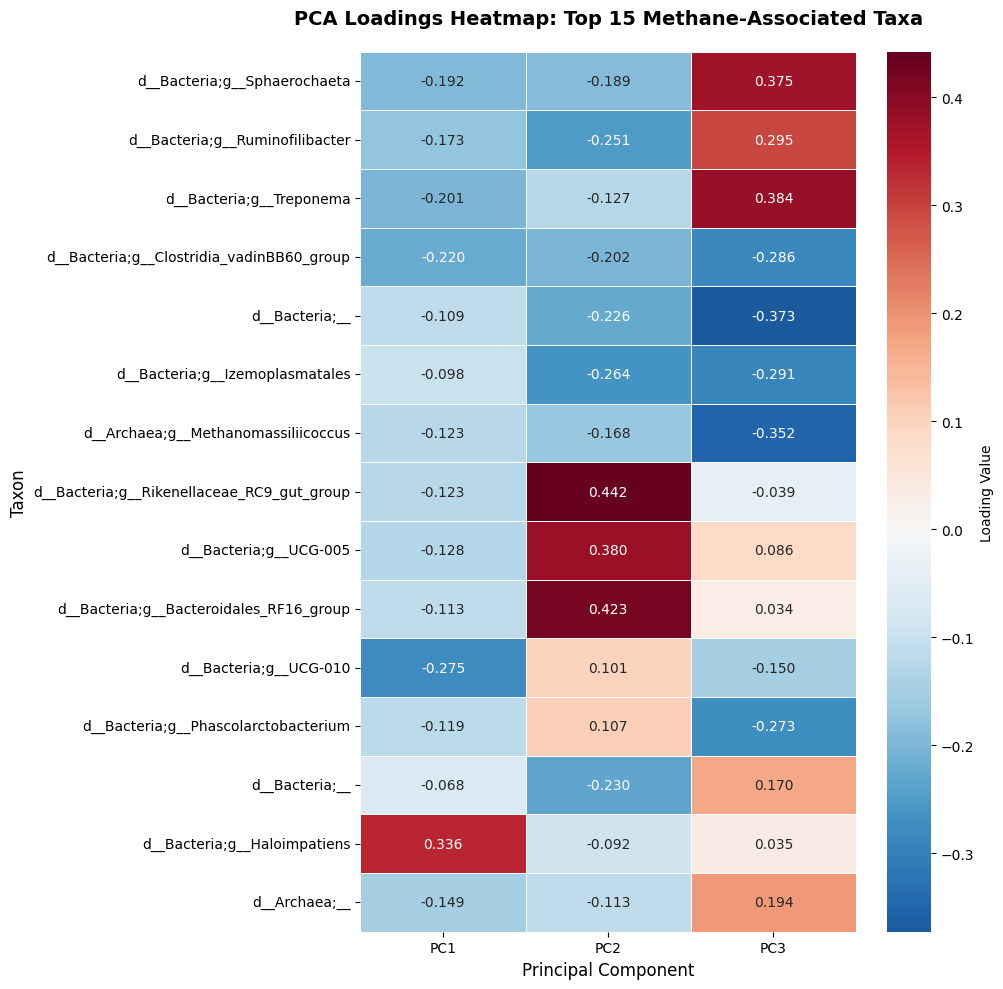

In [243]:
# Additional visualization: Heatmap of loadings for top 15 taxa
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 10))

# Get top 15 taxa
top_15_loadings = importance_table.head(15)[['PC1', 'PC2', 'PC3']]

# Create heatmap
sns.heatmap(top_15_loadings, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, cbar_kws={'label': 'Loading Value'},
            linewidths=0.5, ax=ax)

ax.set_title('PCA Loadings Heatmap: Top 15 Methane-Associated Taxa',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Principal Component', fontsize=12)
ax.set_ylabel('Taxon', fontsize=12)

plt.tight_layout()
plt.savefig("methane_PC_loadings_heatmap.png", dpi=200, bbox_inches='tight')
print("Additional visualization saved: methane_PC_loadings_heatmap.png")
plt.show()

In [244]:
# Weighted loadings: PCA loadings × LMM coefficients for Methane
# This shows the effective contribution of each taxon to Methane prediction in the LMM

# Get LMM coefficients for Methane (excluding intercept)
methane_lmm_coefs = lmm_summary_tables['Methane'].loc[['PC1', 'PC2', 'PC3'], 'Coefficient']

print("="*80)
print("LMM Coefficients for Methane:")
print("="*80)
print(methane_lmm_coefs)

# Calculate weighted loadings: multiply each PC loading by its LMM coefficient
weighted_loadings = loadings.copy()
weighted_loadings['Weighted_PC1'] = weighted_loadings['PC1'] * methane_lmm_coefs['PC1']
weighted_loadings['Weighted_PC2'] = weighted_loadings['PC2'] * methane_lmm_coefs['PC2']
weighted_loadings['Weighted_PC3'] = weighted_loadings['PC3'] * methane_lmm_coefs['PC3']

# Sum weighted contributions across all PCs for each taxon
weighted_loadings['Total_Methane_Effect'] = (
    weighted_loadings['Weighted_PC1'] +
    weighted_loadings['Weighted_PC2'] +
    weighted_loadings['Weighted_PC3']
)

# Sort by absolute total effect
weighted_loadings['Abs_Effect'] = weighted_loadings['Total_Methane_Effect'].abs()
weighted_loadings_sorted = weighted_loadings.sort_values('Abs_Effect', ascending=False)

print("\n" + "="*80)
print("Top 15 Taxa by Effective Contribution to Methane (LMM-weighted)")
print("="*80)
print("\nPositive effect = increases Methane, Negative effect = decreases Methane")
print("\nColumns explanation:")
print("  Weighted_PC1/2/3: PCA loading × LMM coefficient for each PC")
print("  Total_Methane_Effect: Sum of weighted contributions (direct effect on Methane)")
print("="*80)
display_cols = ['Weighted_PC1', 'Weighted_PC2', 'Weighted_PC3', 'Total_Methane_Effect']
print(weighted_loadings_sorted[display_cols].head(15).to_string())

# Save to CSV
weighted_loadings_sorted[['PC1', 'PC2', 'PC3', 'Weighted_PC1', 'Weighted_PC2', 'Weighted_PC3', 'Total_Methane_Effect']].to_csv(
    'methane_weighted_loadings.csv', index=True
)
print("\nWeighted loadings saved to: methane_weighted_loadings.csv")

LMM Coefficients for Methane:
PC1   -3.229623
PC2   -4.638793
PC3    1.971550
Name: Coefficient, dtype: float64

Top 15 Taxa by Effective Contribution to Methane (LMM-weighted)

Positive effect = increases Methane, Negative effect = decreases Methane

Columns explanation:
  Weighted_PC1/2/3: PCA loading × LMM coefficient for each PC
  Total_Methane_Effect: Sum of weighted contributions (direct effect on Methane)
                                            Weighted_PC1  Weighted_PC2  Weighted_PC3  Total_Methane_Effect
d__Bacteria;g__Ruminofilibacter                 0.558321      1.164625      0.582172              2.305118
d__Bacteria;g__Sphaerochaeta                    0.620867      0.878951      0.740071              2.239889
d__Bacteria;g__Treponema                        0.648519      0.587301      0.757668              1.993488
d__Bacteria;g__Rikenellaceae_RC9_gut_group      0.398067     -2.051911     -0.075906             -1.729750
d__Bacteria;__                                  0

Weighted loadings heatmap saved: methane_weighted_loadings_heatmap.png


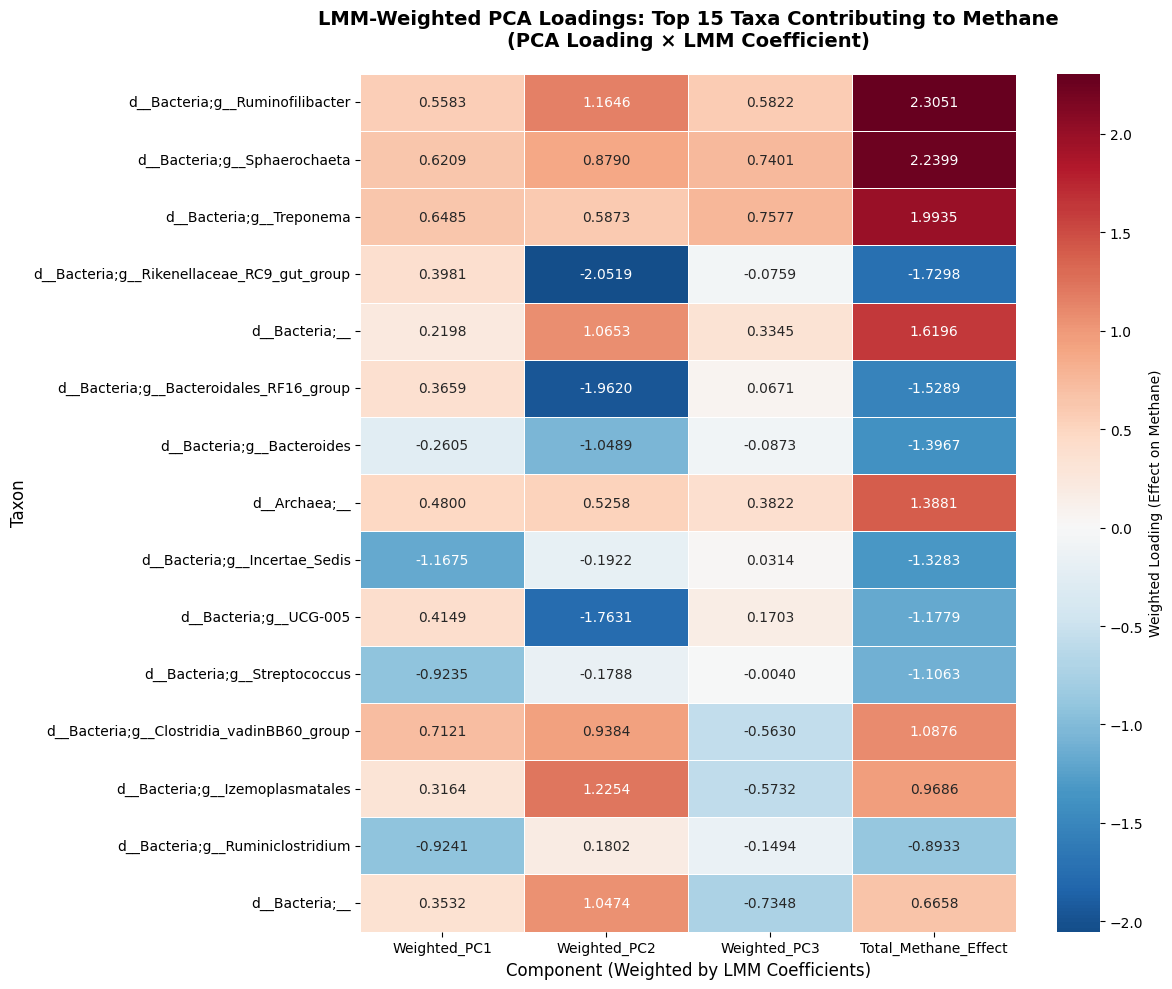

Taxa effects bar plot saved: methane_taxa_effects_barplot.png


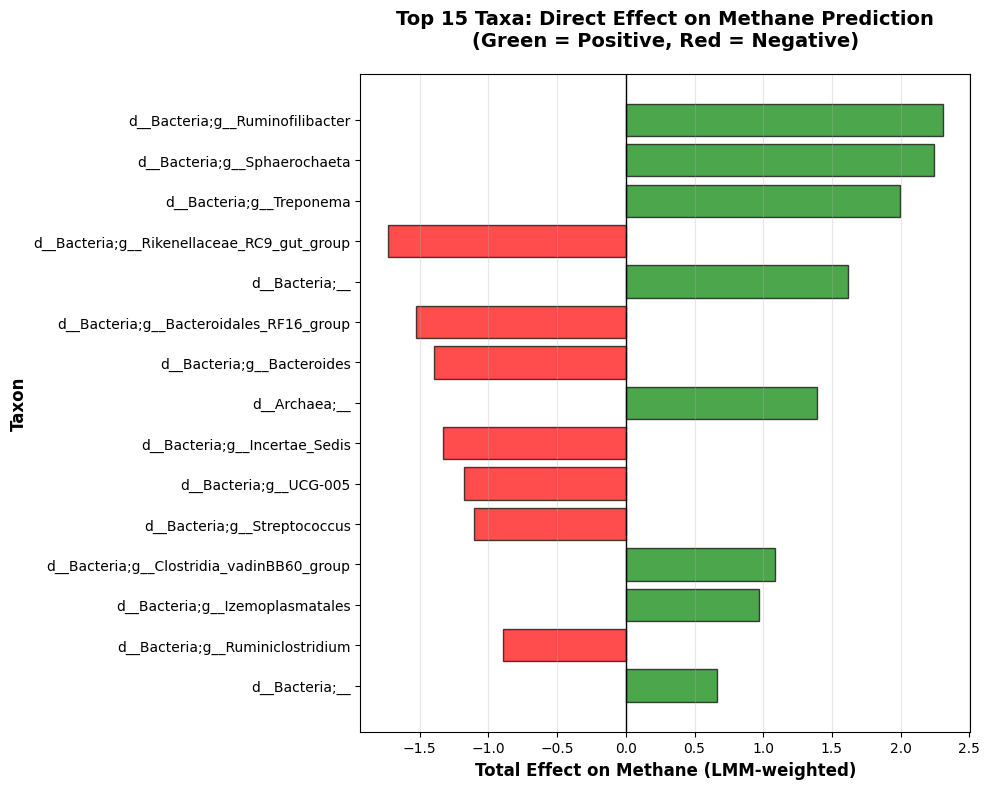

In [245]:
# Heatmap of weighted loadings for top 15 taxa
fig, ax = plt.subplots(figsize=(12, 10))

# Get top 15 taxa by absolute effect
top_15_weighted = weighted_loadings_sorted.head(15)[['Weighted_PC1', 'Weighted_PC2', 'Weighted_PC3', 'Total_Methane_Effect']]

# Create heatmap
sns.heatmap(top_15_weighted, annot=True, fmt='.4f', cmap='RdBu_r',
            center=0, cbar_kws={'label': 'Weighted Loading (Effect on Methane)'},
            linewidths=0.5, ax=ax)

ax.set_title('LMM-Weighted PCA Loadings: Top 15 Taxa Contributing to Methane\n(PCA Loading × LMM Coefficient)',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Component (Weighted by LMM Coefficients)', fontsize=12)
ax.set_ylabel('Taxon', fontsize=12)

plt.tight_layout()
plt.savefig("methane_weighted_loadings_heatmap.png", dpi=200, bbox_inches='tight')
print("Weighted loadings heatmap saved: methane_weighted_loadings_heatmap.png")
plt.show()

# Additional bar plot showing total effect
fig, ax = plt.subplots(figsize=(10, 8))

top_15_for_plot = weighted_loadings_sorted.head(15)
colors = ['green' if x > 0 else 'red' for x in top_15_for_plot['Total_Methane_Effect']]

ax.barh(range(len(top_15_for_plot)), top_15_for_plot['Total_Methane_Effect'], color=colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(top_15_for_plot)))
ax.set_yticklabels(top_15_for_plot.index, fontsize=10)
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Total Effect on Methane (LMM-weighted)', fontsize=12, fontweight='bold')
ax.set_ylabel('Taxon', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Taxa: Direct Effect on Methane Prediction\n(Green = Positive, Red = Negative)',
             fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3)

# Invert y-axis to show highest at top
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("methane_taxa_effects_barplot.png", dpi=200, bbox_inches='tight')
print("Taxa effects bar plot saved: methane_taxa_effects_barplot.png")
plt.show()

# MLP

In [246]:
# Imports for MLP regression
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

# 1. Prepare X, y, and groups
# Filter to match valid_mask (rows without NaN in days)
X = filtered_features.values  # (n_samples, 24) - the taxa features
y = filtered_targets[["Acetic Acid", "Butyric Acid", "Hexanoic Acid", "Methane"]].values  # (n_samples, 4)
groups_array = filtered_groups  # Group labels for stratified split

print("="*80)
print("Data Preparation")
print("="*80)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Groups shape: {groups_array.shape}")
print(f"Unique groups: {np.unique(groups_array)}")

# 2. Stratified 80/20 split (ensuring all groups present in both train and test)
from sklearn.model_selection import train_test_split

# Use stratified split to ensure all groups are represented in both train and test
train_idx, test_idx = train_test_split(
    np.arange(len(X)),
    test_size=0.2,
    random_state=0,
    stratify=groups_array
)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups_array[train_idx]
groups_test = groups_array[test_idx]

print(f"\nTrain/Test Split (stratified by group):")
print(f"  X_train shape: {X_train.shape}")
print(f"  X_test shape: {X_test.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  y_test shape: {y_test.shape}")
print(f"  Train groups: {np.unique(groups_train)}")
print(f"  Test groups: {np.unique(groups_test)}")
print(f"\nGroup distribution in train:")
unique_train, counts_train = np.unique(groups_train, return_counts=True)
for g, c in zip(unique_train, counts_train):
    print(f"    Group {int(g)}: {c} samples")
print(f"Group distribution in test:")
unique_test, counts_test = np.unique(groups_test, return_counts=True)
for g, c in zip(unique_test, counts_test):
    print(f"    Group {int(g)}: {c} samples")

# 3. Build MLP pipeline
# Create the MLP regressor
mlp = MLPRegressor(
    hidden_layer_sizes=(16, 8),  # Two hidden layers: 16 and 8 neurons
    activation='relu',
    solver='adam',
    alpha=1e-3,  # L2 regularization
    max_iter=5000,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=50,
    random_state=0,
    verbose=False
)

# Wrap MLP with target scaling
mlp_with_target_scaling = TransformedTargetRegressor(
    regressor=mlp,
    transformer=StandardScaler()
)

# Create full pipeline with input scaling
mlp_pipeline = Pipeline([
    ("x_scaler", StandardScaler()),
    ("regressor", mlp_with_target_scaling)
])

print("\n" + "="*80)
print("MLP Architecture")
print("="*80)
print(f"Hidden layers: (16, 8)")
print(f"Activation: relu")
print(f"Solver: adam")
print(f"L2 regularization (alpha): 1e-3")
print(f"Early stopping: True (validation_fraction=0.2, n_iter_no_change=50)")
print(f"Input scaling: StandardScaler")
print(f"Target scaling: StandardScaler")

Data Preparation
X shape: (85, 24)
y shape: (85, 4)
Groups shape: (85,)
Unique groups: [1. 2. 3. 4. 5. 6.]

Train/Test Split (stratified by group):
  X_train shape: (68, 24)
  X_test shape: (17, 24)
  y_train shape: (68, 4)
  y_test shape: (17, 4)
  Train groups: [1. 2. 3. 4. 5. 6.]
  Test groups: [1. 2. 3. 4. 5. 6.]

Group distribution in train:
    Group 1: 12 samples
    Group 2: 8 samples
    Group 3: 12 samples
    Group 4: 12 samples
    Group 5: 12 samples
    Group 6: 12 samples
Group distribution in test:
    Group 1: 3 samples
    Group 2: 2 samples
    Group 3: 3 samples
    Group 4: 3 samples
    Group 5: 3 samples
    Group 6: 3 samples

MLP Architecture
Hidden layers: (16, 8)
Activation: relu
Solver: adam
L2 regularization (alpha): 1e-3
Early stopping: True (validation_fraction=0.2, n_iter_no_change=50)
Input scaling: StandardScaler
Target scaling: StandardScaler


In [247]:
# 4. Fit the model
print("\n" + "="*80)
print("Training MLP...")
print("="*80)

mlp_pipeline.fit(X_train, y_train)

print(f"Training complete!")
print(f"Number of iterations: {mlp_pipeline.named_steps['regressor'].regressor_.n_iter_}")
print(f"Best validation score: {mlp_pipeline.named_steps['regressor'].regressor_.best_validation_score_:.4f}")

# 5. Evaluate on test set
print("\n" + "="*80)
print("Model Evaluation on Test Set")
print("="*80)

# Predictions
y_pred = mlp_pipeline.predict(X_test)

# Target names
target_names = ["Acetic Acid", "Butyric Acid", "Hexanoic Acid", "Methane"]

# Compute R² and RMSE for each target
print("\nPer-Target Performance:")
print("-" * 80)
print(f"{'Target':<20} {'R²':<15} {'RMSE':<15}")
print("-" * 80)

r2_scores = []
rmse_scores = []

for i, target_name in enumerate(target_names):
    r2 = r2_score(y_test[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_test[:, i], y_pred[:, i]))
    r2_scores.append(r2)
    rmse_scores.append(rmse)
    print(f"{target_name:<20} {r2:<15.4f} {rmse:<15.4f}")

print("-" * 80)
print(f"{'Mean':<20} {np.mean(r2_scores):<15.4f} {np.mean(rmse_scores):<15.4f}")
print("="*80)

# Store results for comparison
mlp_results = {
    'model': mlp_pipeline,
    'y_pred': y_pred,
    'y_test': y_test,
    'r2_scores': dict(zip(target_names, r2_scores)),
    'rmse_scores': dict(zip(target_names, rmse_scores))
}


Training MLP...
Training complete!
Number of iterations: 473
Best validation score: 0.4701

Model Evaluation on Test Set

Per-Target Performance:
--------------------------------------------------------------------------------
Target               R²              RMSE           
--------------------------------------------------------------------------------
Acetic Acid          -0.0551         2537.6989      
Butyric Acid         -0.5301         1378.1619      
Hexanoic Acid        0.2186          156.1591       
Methane              0.4891          9.9238         
--------------------------------------------------------------------------------
Mean                 0.0306          1020.4859      



Visualization saved: mlp_predictions_vs_actual.png


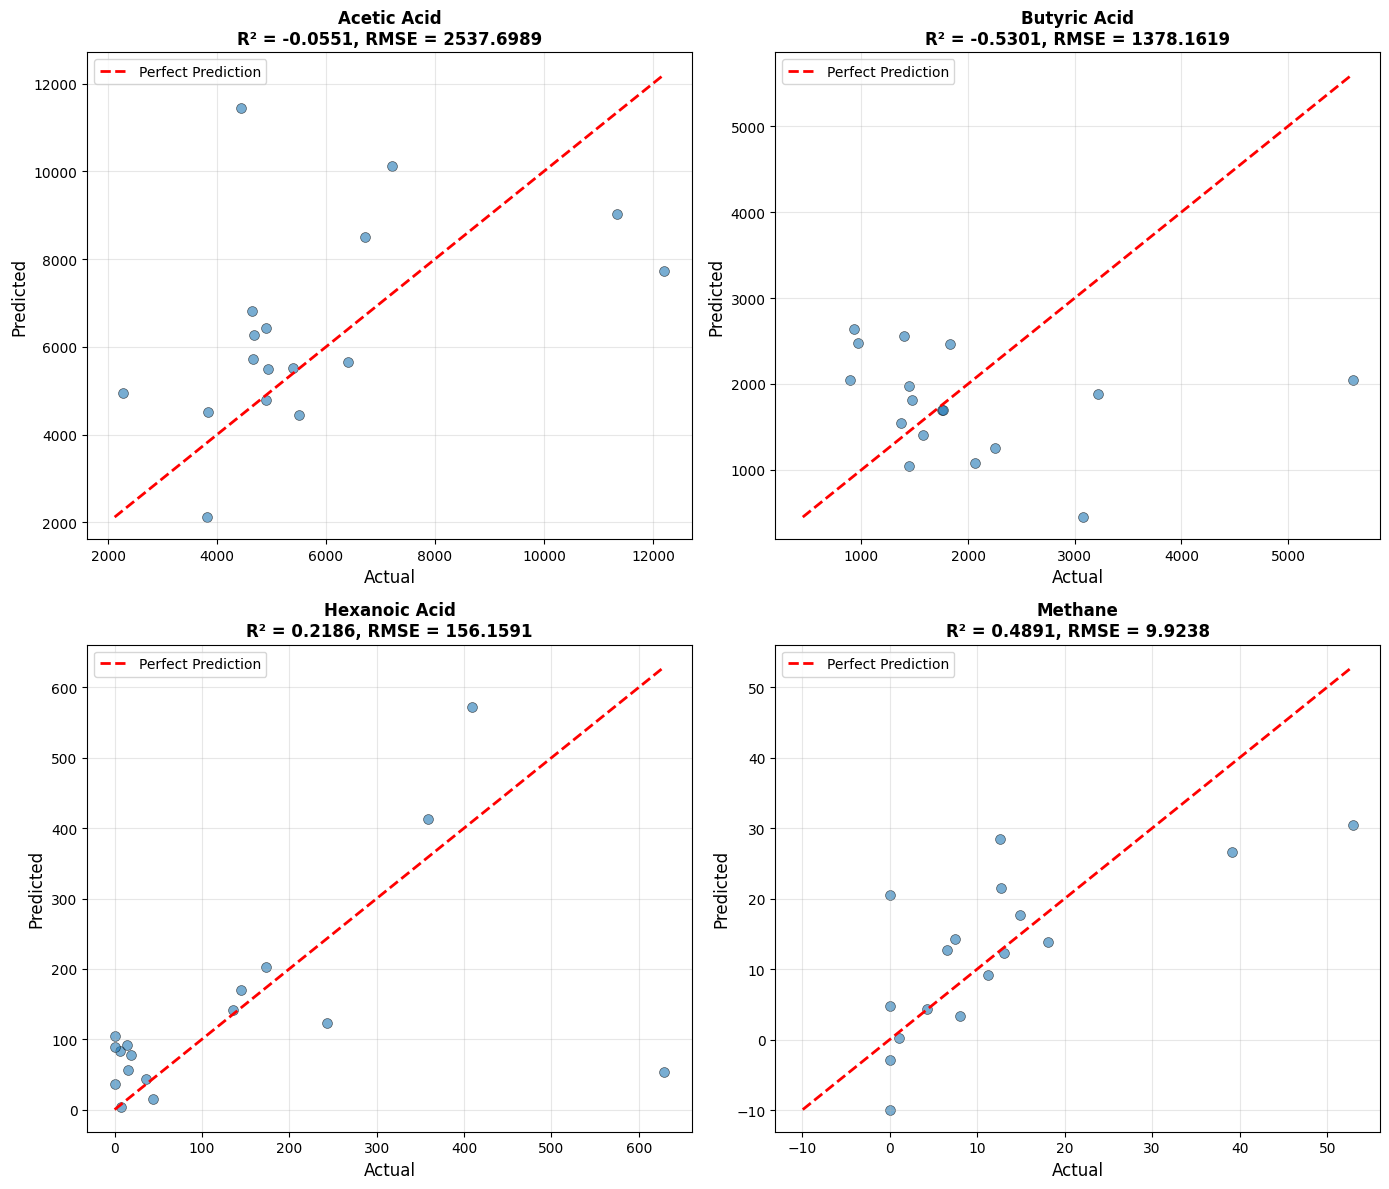

In [248]:
# Visualization: Predicted vs Actual for each target
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, target_name in enumerate(target_names):
    ax = axes[i]

    # Scatter plot
    ax.scatter(y_test[:, i], y_pred[:, i], alpha=0.6, s=50, edgecolors='k', linewidth=0.5)

    # Perfect prediction line
    min_val = min(y_test[:, i].min(), y_pred[:, i].min())
    max_val = max(y_test[:, i].max(), y_pred[:, i].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

    # Labels and title
    ax.set_xlabel('Actual', fontsize=12)
    ax.set_ylabel('Predicted', fontsize=12)
    ax.set_title(f'{target_name}\nR² = {r2_scores[i]:.4f}, RMSE = {rmse_scores[i]:.4f}',
                 fontsize=12, fontweight='bold')
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('mlp_predictions_vs_actual.png', dpi=200, bbox_inches='tight')
print("\nVisualization saved: mlp_predictions_vs_actual.png")
plt.show()

Training loss curve saved: mlp_training_loss_curve.png


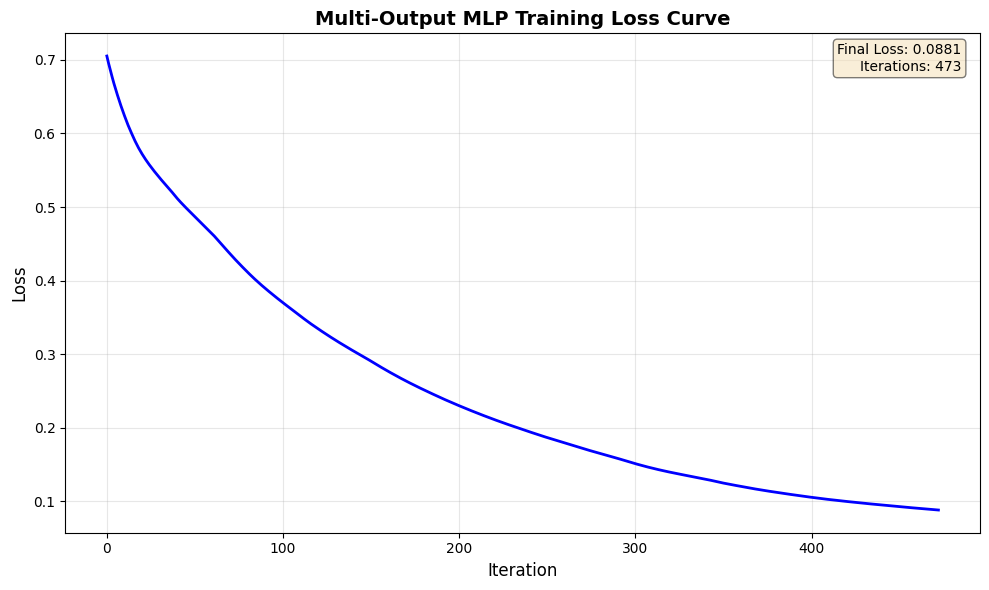

In [249]:
# Plot training loss curve for multi-output MLP
fig, ax = plt.subplots(figsize=(10, 6))

# Get loss curve from the trained model
loss_curve = mlp_pipeline.named_steps['regressor'].regressor_.loss_curve_

ax.plot(loss_curve, linewidth=2, color='blue')
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Multi-Output MLP Training Loss Curve', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
#ax.set_yscale('log')  # Log scale often better for loss curves

# Add text annotation with final loss
final_loss = loss_curve[-1]
ax.text(0.98, 0.98, f'Final Loss: {final_loss:.4f}\nIterations: {len(loss_curve)}',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('mlp_training_loss_curve.png', dpi=200, bbox_inches='tight')
print("Training loss curve saved: mlp_training_loss_curve.png")
plt.show()


Residual plot saved: mlp_residuals.png


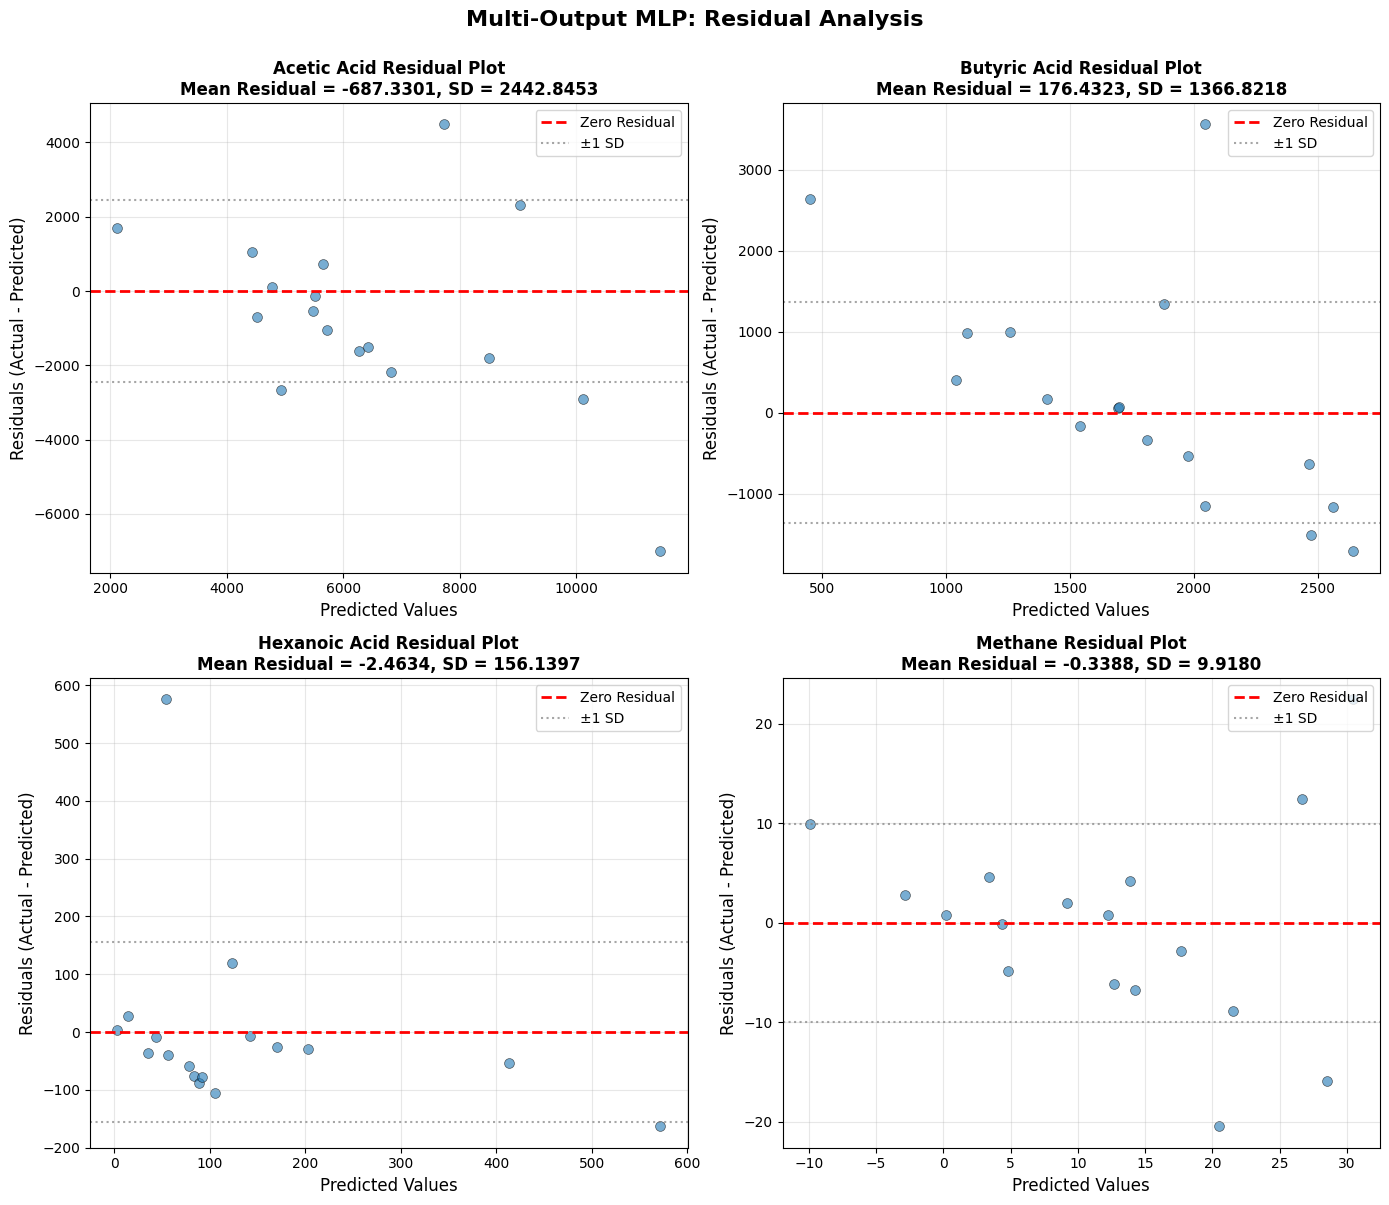


Residual Statistics - Multi-Output MLP

Acetic Acid:
  Mean Residual: -687.330079 (should be close to 0)
  Median Residual: -685.598667
  Std Residual: 2442.845329
  Min Residual: -7009.065475
  Max Residual: 4484.211566

Butyric Acid:
  Mean Residual: 176.432253 (should be close to 0)
  Median Residual: 59.652617
  Std Residual: 1366.821810
  Min Residual: -1711.683171
  Max Residual: 3558.291736

Hexanoic Acid:
  Mean Residual: -2.463371 (should be close to 0)
  Median Residual: -35.724229
  Std Residual: 156.139708
  Min Residual: -163.080781
  Max Residual: 575.422393

Methane:
  Mean Residual: -0.338753 (should be close to 0)
  Median Residual: 0.743447
  Std Residual: 9.917997
  Min Residual: -20.458640
  Max Residual: 22.458214


In [250]:
# Residual plots for multi-output MLP
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, target_name in enumerate(target_names):
    ax = axes[i]

    # Calculate residuals
    residuals = y_test[:, i] - y_pred[:, i]

    # Scatter plot of residuals vs predicted values
    ax.scatter(y_pred[:, i], residuals, alpha=0.6, s=50, edgecolors='k', linewidth=0.5)

    # Horizontal line at y=0 (perfect predictions)
    ax.axhline(y=0, color='r', linestyle='--', lw=2, label='Zero Residual')

    # Add horizontal lines at ±1 std of residuals
    std_residual = np.std(residuals)
    ax.axhline(y=std_residual, color='gray', linestyle=':', lw=1.5, alpha=0.7, label='±1 SD')
    ax.axhline(y=-std_residual, color='gray', linestyle=':', lw=1.5, alpha=0.7)

    # Labels and title
    ax.set_xlabel('Predicted Values', fontsize=12)
    ax.set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
    ax.set_title(f'{target_name} Residual Plot\nMean Residual = {np.mean(residuals):.4f}, SD = {std_residual:.4f}',
                 fontsize=12, fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)

plt.suptitle('Multi-Output MLP: Residual Analysis', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('mlp_residuals.png', dpi=200, bbox_inches='tight')
print("\nResidual plot saved: mlp_residuals.png")
plt.show()

# Print residual statistics
print("\n" + "="*80)
print("Residual Statistics - Multi-Output MLP")
print("="*80)
for i, target_name in enumerate(target_names):
    residuals = y_test[:, i] - y_pred[:, i]
    print(f"\n{target_name}:")
    print(f"  Mean Residual: {np.mean(residuals):.6f} (should be close to 0)")
    print(f"  Median Residual: {np.median(residuals):.6f}")
    print(f"  Std Residual: {np.std(residuals):.6f}")
    print(f"  Min Residual: {np.min(residuals):.6f}")
    print(f"  Max Residual: {np.max(residuals):.6f}")
print("="*80)

In [251]:
# MLP for Methane only (single-output)
print("="*80)
print("MLP for Methane Only")
print("="*80)

# 1. Prepare X and y for Methane
X_methane = filtered_features.values  # (n_samples, 24) - the taxa features
y_methane = filtered_targets["Methane"].values  # (n_samples,) - single target

print(f"X shape: {X_methane.shape}")
print(f"y shape: {y_methane.shape}")
print(f"Groups shape: {groups_array.shape}")

# 2. Stratified 80/20 split (ensuring all groups present in both train and test)
train_idx_methane, test_idx_methane = train_test_split(
    np.arange(len(X_methane)),
    test_size=0.2,
    random_state=0,
    stratify=groups_array
)

X_train_methane = X_methane[train_idx_methane]
X_test_methane = X_methane[test_idx_methane]
y_train_methane = y_methane[train_idx_methane]
y_test_methane = y_methane[test_idx_methane]
groups_train_methane = groups_array[train_idx_methane]
groups_test_methane = groups_array[test_idx_methane]

print(f"\nTrain/Test Split (stratified by group):")
print(f"  X_train shape: {X_train_methane.shape}")
print(f"  X_test shape: {X_test_methane.shape}")
print(f"  y_train shape: {y_train_methane.shape}")
print(f"  y_test shape: {y_test_methane.shape}")
print(f"  Train groups: {np.unique(groups_train_methane)}")
print(f"  Test groups: {np.unique(groups_test_methane)}")
print(f"\nGroup distribution in train:")
unique_train_m, counts_train_m = np.unique(groups_train_methane, return_counts=True)
for g, c in zip(unique_train_m, counts_train_m):
    print(f"    Group {int(g)}: {c} samples")
print(f"Group distribution in test:")
unique_test_m, counts_test_m = np.unique(groups_test_methane, return_counts=True)
for g, c in zip(unique_test_m, counts_test_m):
    print(f"    Group {int(g)}: {c} samples")

# 3. Build MLP pipeline for Methane
print(f"  Train groups: {np.unique(groups_train_methane)}")
print(f"  Test groups: {np.unique(groups_test_methane)}")

# 3. Build MLP pipeline for Methane
mlp_methane = MLPRegressor(
    hidden_layer_sizes=(16, 8),
    activation='relu',
    solver='adam',
    alpha=1e-3,
    max_iter=5000,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=50,
    random_state=0,
    verbose=False
)

mlp_methane_with_target_scaling = TransformedTargetRegressor(
    regressor=mlp_methane,
    transformer=StandardScaler()
)

mlp_methane_pipeline = Pipeline([
    ("x_scaler", StandardScaler()),
    ("regressor", mlp_methane_with_target_scaling)
])

print("\n" + "="*80)
print("MLP Architecture for Methane")
print("="*80)
print(f"Hidden layers: (16, 8)")
print(f"Activation: relu")
print(f"Target: Methane (single output)")

MLP for Methane Only
X shape: (85, 24)
y shape: (85,)
Groups shape: (85,)

Train/Test Split (stratified by group):
  X_train shape: (68, 24)
  X_test shape: (17, 24)
  y_train shape: (68,)
  y_test shape: (17,)
  Train groups: [1. 2. 3. 4. 5. 6.]
  Test groups: [1. 2. 3. 4. 5. 6.]

Group distribution in train:
    Group 1: 12 samples
    Group 2: 8 samples
    Group 3: 12 samples
    Group 4: 12 samples
    Group 5: 12 samples
    Group 6: 12 samples
Group distribution in test:
    Group 1: 3 samples
    Group 2: 2 samples
    Group 3: 3 samples
    Group 4: 3 samples
    Group 5: 3 samples
    Group 6: 3 samples
  Train groups: [1. 2. 3. 4. 5. 6.]
  Test groups: [1. 2. 3. 4. 5. 6.]

MLP Architecture for Methane
Hidden layers: (16, 8)
Activation: relu
Target: Methane (single output)


In [252]:
# 4. Fit the Methane model
print("\n" + "="*80)
print("Training MLP for Methane...")
print("="*80)

mlp_methane_pipeline.fit(X_train_methane, y_train_methane)

print(f"Training complete!")
print(f"Number of iterations: {mlp_methane_pipeline.named_steps['regressor'].regressor_.n_iter_}")
print(f"Best validation score: {mlp_methane_pipeline.named_steps['regressor'].regressor_.best_validation_score_:.4f}")

# 5. Evaluate on test set
print("\n" + "="*80)
print("Model Evaluation on Test Set - Methane")
print("="*80)

# Predictions
y_pred_methane = mlp_methane_pipeline.predict(X_test_methane)

# Compute R² and RMSE
r2_methane = r2_score(y_test_methane, y_pred_methane)
rmse_methane = np.sqrt(mean_squared_error(y_test_methane, y_pred_methane))

print(f"\nMethane Performance:")
print("-" * 80)
print(f"R² Score: {r2_methane:.4f}")
print(f"RMSE: {rmse_methane:.4f}")
print("="*80)

# Store results
mlp_methane_results = {
    'model': mlp_methane_pipeline,
    'y_pred': y_pred_methane,
    'y_test': y_test_methane,
    'r2': r2_methane,
    'rmse': rmse_methane
}


Training MLP for Methane...
Training complete!
Number of iterations: 166
Best validation score: 0.2135

Model Evaluation on Test Set - Methane

Methane Performance:
--------------------------------------------------------------------------------
R² Score: 0.3250
RMSE: 11.4067



Visualization saved: mlp_methane_predictions_vs_actual.png


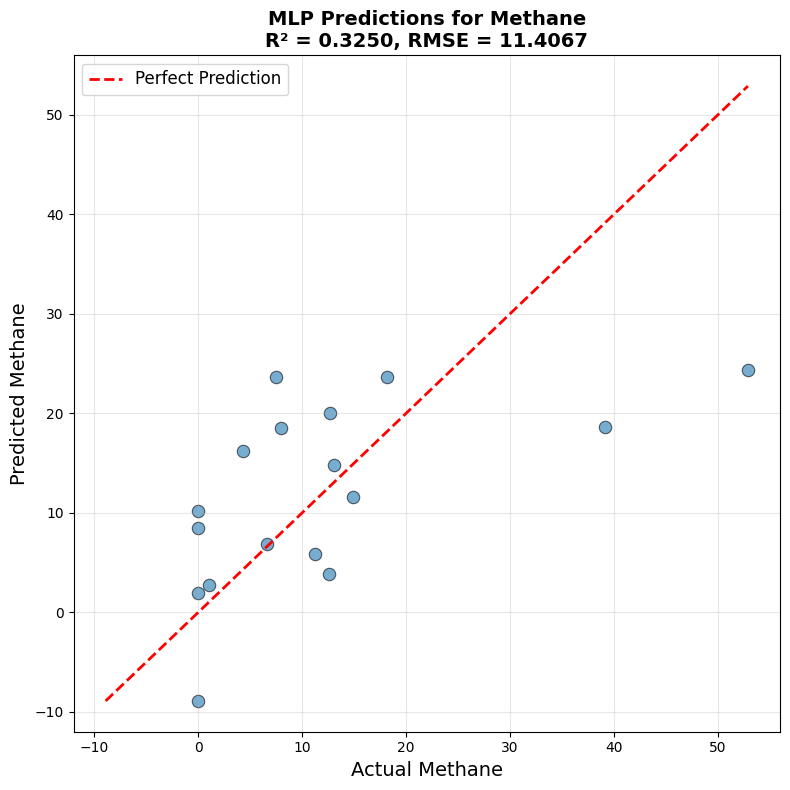

In [253]:
# Visualization: Predicted vs Actual for Methane
fig, ax = plt.subplots(figsize=(8, 8))

# Scatter plot
ax.scatter(y_test_methane, y_pred_methane, alpha=0.6, s=80, edgecolors='k', linewidth=0.8)

# Perfect prediction line
min_val = min(y_test_methane.min(), y_pred_methane.min())
max_val = max(y_test_methane.max(), y_pred_methane.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

# Labels and title
ax.set_xlabel('Actual Methane', fontsize=14)
ax.set_ylabel('Predicted Methane', fontsize=14)
ax.set_title(f'MLP Predictions for Methane\nR² = {r2_methane:.4f}, RMSE = {rmse_methane:.4f}',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('mlp_methane_predictions_vs_actual.png', dpi=200, bbox_inches='tight')
print("\nVisualization saved: mlp_methane_predictions_vs_actual.png")
plt.show()

Training loss curve saved: mlp_methane_training_loss_curve.png


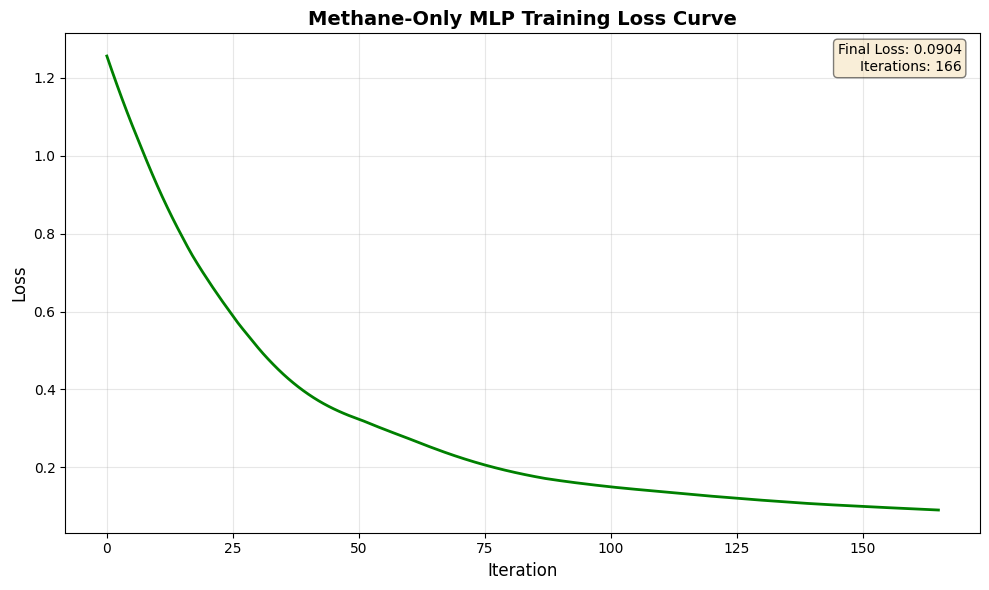

In [254]:
# Plot training loss curve for Methane-only MLP
fig, ax = plt.subplots(figsize=(10, 6))

# Get loss curve from the trained model
loss_curve_methane = mlp_methane_pipeline.named_steps['regressor'].regressor_.loss_curve_

ax.plot(loss_curve_methane, linewidth=2, color='green')
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Methane-Only MLP Training Loss Curve', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
#ax.set_yscale('log')  # Log scale often better for loss curves

# Add text annotation with final loss
final_loss_methane = loss_curve_methane[-1]
ax.text(0.98, 0.98, f'Final Loss: {final_loss_methane:.4f}\nIterations: {len(loss_curve_methane)}',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('mlp_methane_training_loss_curve.png', dpi=200, bbox_inches='tight')
print("Training loss curve saved: mlp_methane_training_loss_curve.png")
plt.show()


Residual plot saved: mlp_methane_residuals.png


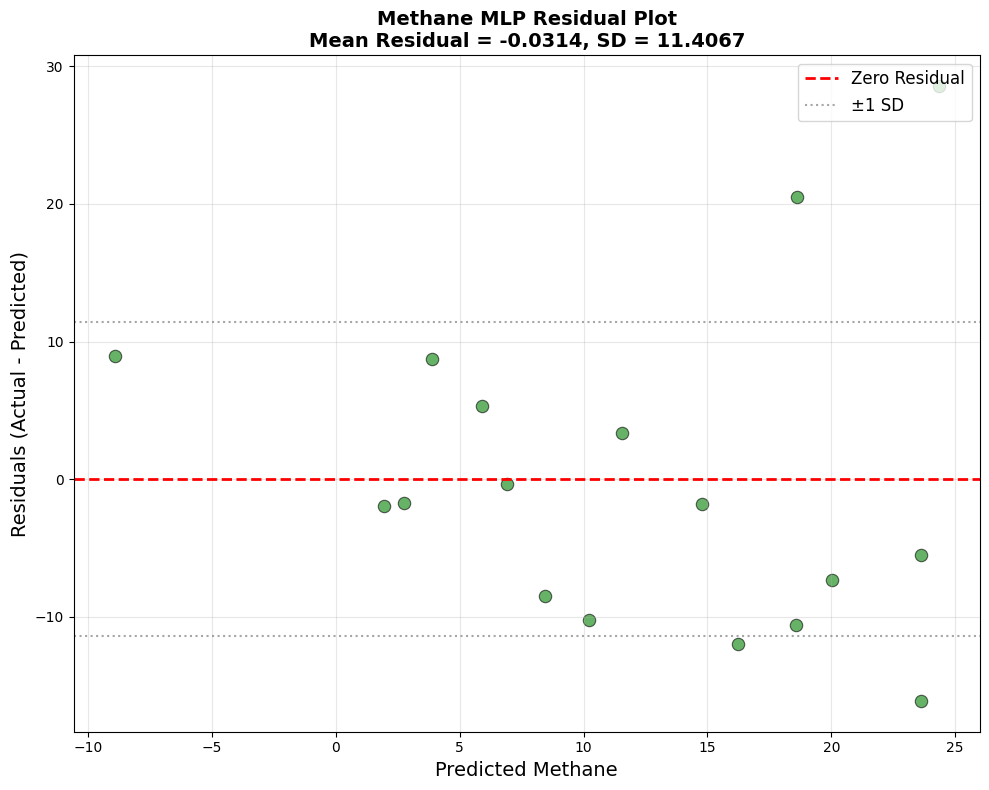


Residual Statistics - Methane MLP
Mean Residual: -0.031367 (should be close to 0)
Median Residual: -1.773065
Std Residual: 11.406696
Min Residual: -16.099603
Max Residual: 28.549809
Skewness: 1.0599 (should be close to 0)
Kurtosis: 0.9945 (excess kurtosis, should be close to 0)


In [255]:
# Residual plot for Methane-only MLP
fig, ax = plt.subplots(figsize=(10, 8))

# Calculate residuals
residuals_methane = y_test_methane - y_pred_methane

# Scatter plot of residuals vs predicted values
ax.scatter(y_pred_methane, residuals_methane, alpha=0.6, s=80, edgecolors='k', linewidth=0.8, color='green')

# Horizontal line at y=0 (perfect predictions)
ax.axhline(y=0, color='r', linestyle='--', lw=2, label='Zero Residual')

# Add horizontal lines at ±1 std of residuals
std_residual_methane = np.std(residuals_methane)
ax.axhline(y=std_residual_methane, color='gray', linestyle=':', lw=1.5, alpha=0.7, label='±1 SD')
ax.axhline(y=-std_residual_methane, color='gray', linestyle=':', lw=1.5, alpha=0.7)

# Labels and title
ax.set_xlabel('Predicted Methane', fontsize=14)
ax.set_ylabel('Residuals (Actual - Predicted)', fontsize=14)
ax.set_title(f'Methane MLP Residual Plot\nMean Residual = {np.mean(residuals_methane):.4f}, SD = {std_residual_methane:.4f}',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('mlp_methane_residuals.png', dpi=200, bbox_inches='tight')
print("\nResidual plot saved: mlp_methane_residuals.png")
plt.show()

# Print residual statistics
print("\n" + "="*80)
print("Residual Statistics - Methane MLP")
print("="*80)
print(f"Mean Residual: {np.mean(residuals_methane):.6f} (should be close to 0)")
print(f"Median Residual: {np.median(residuals_methane):.6f}")
print(f"Std Residual: {std_residual_methane:.6f}")
print(f"Min Residual: {np.min(residuals_methane):.6f}")
print(f"Max Residual: {np.max(residuals_methane):.6f}")
print(f"Skewness: {pd.Series(residuals_methane).skew():.4f} (should be close to 0)")
print(f"Kurtosis: {pd.Series(residuals_methane).kurtosis():.4f} (excess kurtosis, should be close to 0)")
print("="*80)